Multi-Channel churn Classifier: A Mini-Project by Aditya Raj

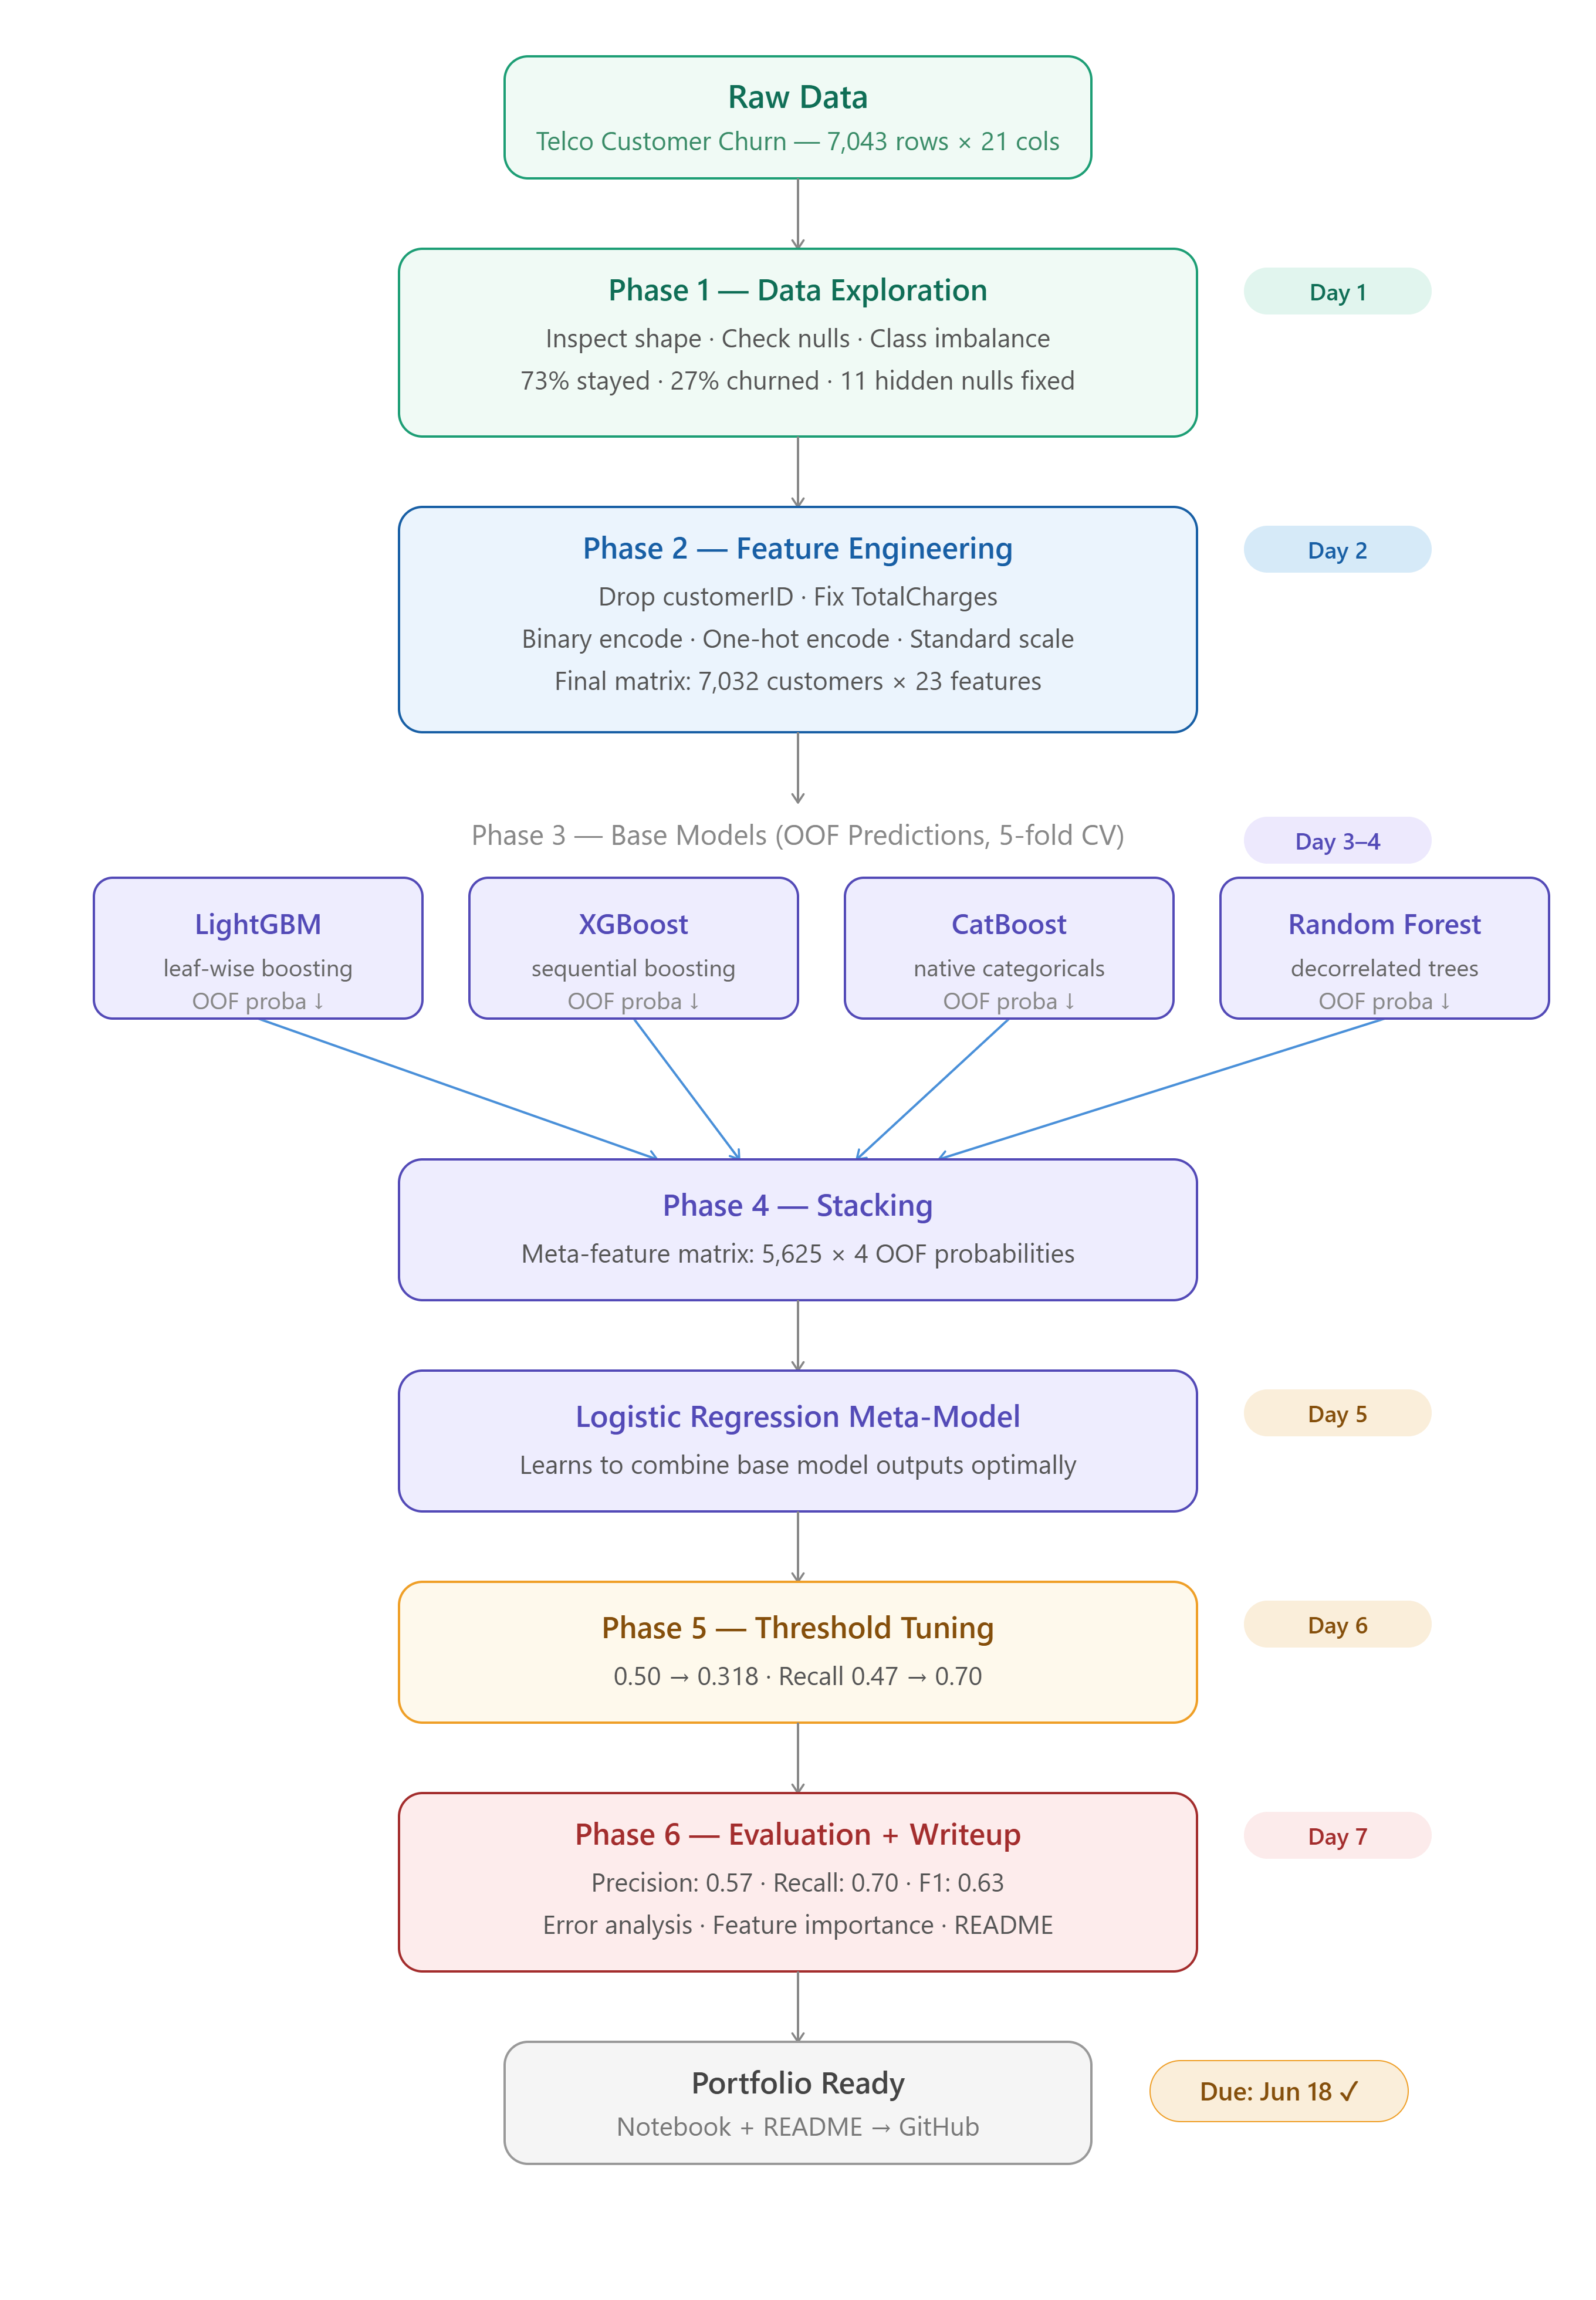

In [14]:
import pandas as pd

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna(subset=['TotalCharges'])
df = df.drop(columns=['customerID'])
df['Churn'] = (df['Churn'] == 'Yes').astype(int)
df['gender'] = (df['gender'] == 'Male').astype(int)

binary_cols = ['Partner', 'Dependents', 'PhoneService',
               'PaperlessBilling', 'MultipleLines', 'OnlineSecurity',
               'OnlineBackup', 'DeviceProtection', 'TechSupport',
               'StreamingTV', 'StreamingMovies']

df[binary_cols] = df[binary_cols].apply(lambda x: (x == 'Yes').astype(int))

print(df['gender'].value_counts())
print(df.shape)

gender
1    3549
0    3483
Name: count, dtype: int64
(7032, 20)


In [15]:
multi_cols = ['InternetService', 'Contract', 'PaymentMethod']

df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

print(df.shape)
print(df.columns.tolist())

(7032, 24)
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# separate features and target
X = df.drop(columns=['Churn'])
y = df['Churn']

# scale numerical columns
scaler = StandardScaler()
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
X[num_cols] = scaler.fit_transform(X[num_cols])

# train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)
print(y_train.value_counts())

(5625, 23)
(1407, 23)
Churn
0    4130
1    1495
Name: count, dtype: int64


In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_oof = cross_val_predict(rf, X_train, y_train, cv=5, method='predict_proba')

print(rf_oof.shape)

(5625, 2)


In [18]:
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb_oof = cross_val_predict(xgb, X_train, y_train, cv=5, method='predict_proba')

print(xgb_oof.shape)

(5625, 2)


In [19]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(n_estimators=100, random_state=42)
lgbm_oof = cross_val_predict(lgbm, X_train, y_train, cv=5, method='predict_proba')

print(lgbm_oof.shape)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1196, number of negative: 3304
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001975 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 623
[LightGBM] [Info] Number of data points in the train set: 4500, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265778 -> initscore=-1.016151
[LightGBM] [Info] Start training from score -1.016151
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1196, number of negative: 3304
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000902 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 623
[LightGBM] [Info] Numb

In [21]:
!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.8 MB/s eta 0:00:00


In [22]:
from catboost import CatBoostClassifier

cat = CatBoostClassifier(n_estimators=100, random_state=42, verbose=0)
cat_oof = cross_val_predict(cat, X_train, y_train, cv=5, method='predict_proba')

print(cat_oof.shape)

(5625, 2)


In [23]:
import numpy as np

meta_train = np.column_stack([
    rf_oof[:, 1],
    xgb_oof[:, 1],
    lgbm_oof[:, 1],
    cat_oof[:, 1]
])

print(meta_train.shape)

(5625, 4)


In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

meta_model = LogisticRegression(random_state=42)
meta_model.fit(meta_train, y_train)

meta_train_preds = meta_model.predict(meta_train)
print(classification_report(y_train, meta_train_preds))

              precision    recall  f1-score   support

           0       0.83      0.91      0.87      4130
           1       0.67      0.48      0.56      1495

    accuracy                           0.80      5625
   macro avg       0.75      0.70      0.72      5625
weighted avg       0.79      0.80      0.79      5625



In [25]:
# fit all base models on full training data
rf.fit(X_train, y_train)
xgb.fit(X_train, y_train)
lgbm.fit(X_train, y_train)
cat.fit(X_train, y_train)

# get test probabilities from each base model
meta_test = np.column_stack([
    rf.predict_proba(X_test)[:, 1],
    xgb.predict_proba(X_test)[:, 1],
    lgbm.predict_proba(X_test)[:, 1],
    cat.predict_proba(X_test)[:, 1]
])

# meta-model predicts on test
test_preds = meta_model.predict(meta_test)
print(classification_report(y_test, test_preds))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1495, number of negative: 4130
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001171 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 623
[LightGBM] [Info] Number of data points in the train set: 5625, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265778 -> initscore=-1.016151
[LightGBM] [Info] Start training from score -1.016151
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1033
           1       0.62      0.47      0.54       374

    accuracy                           0.78      1407
   macro avg       0.72      0.68      0.70      1407
weighted avg       0.77      0.78      0.77      1407



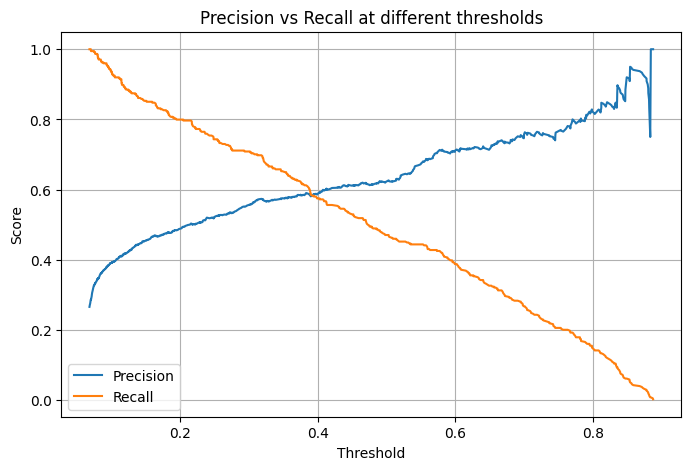

In [26]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

meta_test_proba = meta_model.predict_proba(meta_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, meta_test_proba)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision vs Recall at different thresholds')
plt.legend()
plt.grid(True)
plt.show()

In [27]:
# find threshold that maximises F1
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1])
optimal_threshold = thresholds[f1_scores.argmax()]
print(f'Optimal threshold: {optimal_threshold:.3f}')

# apply it
final_preds = (meta_test_proba >= optimal_threshold).astype(int)
print(classification_report(y_test, final_preds))

Optimal threshold: 0.318
              precision    recall  f1-score   support

           0       0.88      0.81      0.85      1033
           1       0.57      0.70      0.63       374

    accuracy                           0.78      1407
   macro avg       0.73      0.76      0.74      1407
weighted avg       0.80      0.78      0.79      1407



In [28]:
import numpy as np

# get all test customers as dataframe
results = X_test.copy()
results['actual'] = y_test.values
results['predicted'] = final_preds
results['churn_probability'] = meta_test_proba

# find false negatives — churners the model missed
false_negatives = results[(results['actual'] == 1) & (results['predicted'] == 0)]
print(f"Total missed churners: {len(false_negatives)}")
print()
print(false_negatives.iloc[0])

Total missed churners: 113

gender                                          0
SeniorCitizen                                   0
Partner                                         0
Dependents                                      0
tenure                                  -1.239504
PhoneService                                    1
MultipleLines                                   0
OnlineSecurity                                  0
OnlineBackup                                    0
DeviceProtection                                0
TechSupport                                     0
StreamingTV                                     0
StreamingMovies                                 0
PaperlessBilling                                0
MonthlyCharges                          -1.467506
TotalCharges                             -0.99029
InternetService_Fiber optic                 False
InternetService_No                           True
Contract_One year                           False
Contract_Two year     